<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Exercise.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

# Exercise: Decision trees
© ExploreAI Academy

In this exercise, we will test our knowledge of the fundamental concepts of decision trees by implementing a decision tree regression model and analysing its performance metrics.

By the end of this exercise, you should be able to:
* Implement a decision tree regression model.

# Initial data exploration

We will be using our agriculture dataset to explore the effect climate change has on crops in Maji Ndogo. As a refresher of our data, examine the data dictionary.

# Data dictionary

**1. Geographic features**

- **Field_ID:** A unique identifier for each field (BigInt).
 
- **Elevation:** The elevation of the field above sea level in metres (Float).

- **Latitude:** Geographical latitude of the field in degrees (Float). (DUMMY VARIABLE – the simulation might have created a relationship)

- **Longitude:** Geographical longitude of the field in degrees (Float). (DUMMY VARIABLE – the simulation might have created a relationship)

- **Location:** Province the field is in (Text).

- **Slope:** The slope of the land in the field (Float).

**2. Weather features**

- **Rainfall:** Amount of rainfall in the area in mm (Float).

- **Min_temperature_C:** Average minimum temperature recorded in Celsius (Float). (DUMMY VARIABLE)

- **Max_temperature_C:** Average maximum temperature recorded in Celsius (Float). (DUMMY VARIABLE)

- **Ave_temps:** Average temperature in Celsius (Float).

**3. Soil and crop features**

- **Soil_fertility:** A measure of soil fertility where 0 is infertile soil and 1 is very fertile soil (Float).

- **Soil_type:** Type of soil present in the field (Text).

- **pH:** pH level of the soil, which is a measure of how acidic/basic the soil is (Float).

**4. Farm management features**

- **Field_ID:** Corresponding field identifier (BigInt).

- **Pollution_level:** Level of pollution in the area where 0 is unpolluted and 1 is very polluted (Float).

- **Plot_size:** Size of the plot in the field (Ha) (Float). (DUMMY VARIABLE)

- **Crop_type:** Type of crop chosen for cultivation (Text).

- **Annual_yield:** Annual yield from the field (Float). This is the total output of the field. The field size and type of crop will affect the annual yield. (DUMMY VARIABLE – removed)

<br>

**5. Target variable**
- **Standard_yield:** Standardised yield expected from the field, normalised per crop (Float). This is independent of field size or crop type. Multiplying this number by the field size and average crop yield will give the Annual_yield.

---

Let's import our database again, like we did last time. We won't use the weather data so it is commented out.

**Important:** Ensure that `data_ingestion.py` file and the `field_data_processor.py` files are stored in the same folder as your notebook, and check that the database file is created correctly, otherwise the data import will fail.
 
[Download files here](https://github.com/Explore-AI/Public-Data/raw/master/Maji_Ndogo/modules.zip)


In [100]:
# Read the database, and clean the data using the processing modules we built.

import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
# from weather_data_processor import WeatherDataProcessor
import logging 

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

config_params = {
    "sql_query": """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (Field_ID)
            LEFT JOIN soil_and_crop_features USING (Field_ID)
            LEFT JOIN farm_management_features USING (Field_ID)
            """,
    "db_path": 'sqlite:///Maji_Ndogo_farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns" : {
            'Rainfall': r'(\d+(\.\d+)?)\s?mm',
            'Temperature': r'(\d+(\.\d+)?)\s?C',
            'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
            },
}
# Ignoring the field data for now.
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
# weather_processor = WeatherDataProcessor(config_params)
# weather_processor.process()
# weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2026-07-31 15:37:21,261 - data_ingestion - INFO - Database engine created successfully.
2026-07-31 15:37:21,335 - data_ingestion - INFO - Query executed successfully.
2026-07-31 15:37:21,335 - field_data_processor.FieldDataProcessor - INFO - Sucessfully loaded data.
2026-07-31 15:37:21,335 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-07-31 15:37:22,011 - field_data_processor.FieldDataProcessor - INFO - CSV file read successfully from the web.
2026-07-31 15:37:22,012 - field_data_processor.FieldDataProcessor - INFO - Weather station mapping merged successfully.


Let's take a quick look at our dataset to ensure it imported correctly.

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
import seaborn as sns
import matplotlib.pyplot as plt

Before diving into our analysis, it's crucial to ensure the integrity of our dataset and that the data are still as we expect it to be.

In [102]:
# Validate the data
# !pip install pytest

dataset.to_csv('sampled_field_df.csv', index=False)



import os# Define the file paths
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f"Deleted {field_csv_path}")
else:
    print(f"{field_csv_path} does not exist.")

Deleted sampled_field_df.csv


## Exercises

### Exercise 1 

To begin our exploration of the dataset, we will use a decision tree to explore how all of the variables affect our crop yields.

Given our dataset containing information on environmental factors and crop yields, how can we train a decision tree model to predict crop yields accurately?

Fit a decision tree regressor model to the entire dataset.

Use all predictor variables (excluding non-numeric columns) to predict `Standard_yield`. 

Set the `max_depth` to 4 and the `random_state` to 42 for reproducibility.

Considering the **MSE** and **R²** values, how effective is the decision tree in predicting crop yields using all of our variables?

In [103]:
df= dataset.copy()
df.head()

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield,Unnamed: 0
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964,0
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302,1
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647,2
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348,3
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076,4


In [104]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.shape

(5654, 18)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Field_ID           5654 non-null   int64  
 1   Elevation          5654 non-null   float64
 2   Latitude           5654 non-null   float64
 3   Longitude          5654 non-null   float64
 4   Location           5654 non-null   object 
 5   Slope              5654 non-null   float64
 6   Rainfall           5654 non-null   float64
 7   Min_temperature_C  5654 non-null   float64
 8   Max_temperature_C  5654 non-null   float64
 9   Ave_temps          5654 non-null   float64
 10  Soil_fertility     5654 non-null   float64
 11  Soil_type          5654 non-null   object 
 12  pH                 5654 non-null   float64
 13  Pollution_level    5654 non-null   float64
 14  Plot_size          5654 non-null   float64
 15  Annual_yield       5654 non-null   float64
 16  Crop_type          5654 

In [106]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Field_ID,5654.0,22632.733817,13133.762515,1.000000e+00,11463.250000,22615.500000,34077.750000,45153.000000
Elevation,5654.0,637.790709,173.573934,3.591080e+01,525.611413,663.058585,764.299550,1122.252100
Latitude,5654.0,-7.026330,3.515839,-1.500904e+01,-9.674298,-7.205178,-4.182984,0.260756
Longitude,5654.0,-4.365755,2.706603,-1.001572e+01,-6.708209,-4.463785,-2.015527,1.696276
Slope,5654.0,11.742669,9.540599,9.731625e-02,4.860120,9.104626,15.953242,79.865960
Rainfall,5654.0,1201.943244,499.782824,1.031000e+02,773.175000,1200.600000,1625.425000,2470.900000
Min_temperature_C,5654.0,-4.411956,1.534330,-9.700000e+00,-5.500000,-4.300000,-3.300000,-0.100000
Max_temperature_C,5654.0,30.857057,1.884682,2.450000e+01,29.600000,30.800000,32.100000,37.800000
Ave_temps,5654.0,13.222550,0.801636,1.025000e+01,12.700000,13.200000,13.750000,17.300000
Soil_fertility,5654.0,0.619308,0.044791,5.100000e-01,0.590000,0.620000,0.650000,0.820000


In [107]:
df_numeric = df.select_dtypes(include=[np.number])
df_categorical = df.select_dtypes(exclude=[np.number])

df_categorical.columns

Index(['Location', 'Soil_type', 'Crop_type'], dtype='object')

In [108]:
# encode the categorical variables using one-hot encoding
df_categorical = pd.get_dummies(df_categorical, drop_first=True)
df_encoded = pd.concat([df_numeric, df_categorical], axis=1)

# convert encoded categorical variables 0 and 1 to float
df_encoded = df_encoded.astype(float)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Field_ID                 5654 non-null   float64
 1   Elevation                5654 non-null   float64
 2   Latitude                 5654 non-null   float64
 3   Longitude                5654 non-null   float64
 4   Slope                    5654 non-null   float64
 5   Rainfall                 5654 non-null   float64
 6   Min_temperature_C        5654 non-null   float64
 7   Max_temperature_C        5654 non-null   float64
 8   Ave_temps                5654 non-null   float64
 9   Soil_fertility           5654 non-null   float64
 10  pH                       5654 non-null   float64
 11  Pollution_level          5654 non-null   float64
 12  Plot_size                5654 non-null   float64
 13  Annual_yield             5654 non-null   float64
 14  Standard_yield          

In [109]:
df = df_encoded.copy()

In [110]:
# scaterplot of the target variable(Standard_yield) against the features
# adding the line of best fit to the scatter plot to visualize the relationship between the features and the target variable.

import matplotlib.pyplot as plt

# for col in df.columns:
#     if col != 'Standard_yield':
#         plt.figure(figsize=(8, 6))
#         sns.scatterplot(x=df[col], y=df['Standard_yield'])
#         sns.regplot(x=df[col], y=df['Standard_yield'], scatter=False, color='red')
#         plt.title(f'Scatter plot of Standard_yield vs {col}')
#         plt.xlabel(col)
#         plt.ylabel('Standard_yield')
#         plt.show()

In [111]:
df.columns

Index(['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Slope', 'Rainfall',
       'Min_temperature_C', 'Max_temperature_C', 'Ave_temps', 'Soil_fertility',
       'pH', 'Pollution_level', 'Plot_size', 'Annual_yield', 'Standard_yield',
       'Location_Rural_Amanzi', 'Location_Rural_Hawassa',
       'Location_Rural_Kilimani', 'Location_Rural_Sokoto', 'Soil_type_Peaty',
       'Soil_type_Rocky', 'Soil_type_Sandy', 'Soil_type_Silt',
       'Soil_type_Volcanic', 'Crop_type_cassava', 'Crop_type_cassava ',
       'Crop_type_coffee', 'Crop_type_maize', 'Crop_type_potato',
       'Crop_type_rice', 'Crop_type_tea', 'Crop_type_tea ', 'Crop_type_wheat',
       'Crop_type_wheat '],
      dtype='object')

In [112]:
# # variable selection using variance threshold method to remove features with low variance, which are less likely to be useful for prediction.
# from sklearn.feature_selection import VarianceThreshold

# # create a VarianceThreshold object with a threshold of 0.1
# selector = VarianceThreshold(threshold=0.1)

# # fit the selector on the dataframe
# selector.fit(df)

# # get the boolean mask of the selected features
# selected_features = selector.get_support()

# # get the names of the selected features
# feature_names = df.columns[selected_features]

# print("Selected features:")
# print(feature_names)

In [113]:
X = df.drop('Standard_yield', axis=1)
y = df['Standard_yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
# initialize the DecisionTreeRegressor model
decision_tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
decision_tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [115]:
# Training and Testing model predictions
decision_tree_train_predictions = decision_tree_model.predict(X_train)
decision_tree_test_predictions = decision_tree_model.predict(X_test)

In [116]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
train_residuals = y_train - decision_tree_train_predictions
test_residuals = y_test - decision_tree_test_predictions

In [117]:
# Train model evaluation
train_mse = mean_squared_error(y_train, decision_tree_train_predictions)
train_r2 = r2_score(y_train, decision_tree_train_predictions)
train_rmse = root_mean_squared_error(y_train, decision_tree_train_predictions)
train_rss = np.sum(train_residuals**2)

dec_train_model_evaluation = {
    'train_mse': train_mse,
    'train_r2': train_r2,
    'train_rmse': train_rmse,
    'train_rss': train_rss
}

pd.DataFrame(dec_train_model_evaluation, index=[0])

,train_mse,train_r2,train_rmse,train_rss
0,0.004668,0.619909,0.068322,21.11294


In [118]:
# Test model evaluation
test_mse = mean_squared_error(y_test, decision_tree_test_predictions)
test_r2 = r2_score(y_test, decision_tree_test_predictions)
test_rmse = root_mean_squared_error(y_test, decision_tree_test_predictions)
test_rss = np.sum(test_residuals**2)

dec_test_model_evaluation = {
    'test_mse': test_mse,
    'test_r2': test_r2,
    'test_rmse': test_rmse,
    'test_rss': test_rss
}
pd.DataFrame(dec_test_model_evaluation, index=[0])

,test_mse,test_r2,test_rmse,test_rss
0,0.004957,0.628026,0.070404,5.606047


In [119]:
# comparing the training and testing model evaluation metrics to assess the performance of the Decision Tree model and check for overfitting or underfitting.
model_evaluation_comparison = {
    'train_mse': train_mse,
    'train_r2': train_r2,
    'train_rmse': train_rmse,
    'train_rss': train_rss,
    'test_mse': test_mse,
    'test_r2': test_r2,
    'test_rmse': test_rmse,
    'test_rss': test_rss
}

# convert the dictionary to a DataFrame for better visualization
model_evaluation_comparison_df = pd.DataFrame(model_evaluation_comparison, index=[0])
model_evaluation_comparison_df

,train_mse,train_r2,train_rmse,train_rss,test_mse,test_r2,test_rmse,test_rss
0,0.004668,0.619909,0.068322,21.11294,0.004957,0.628026,0.070404,5.606047


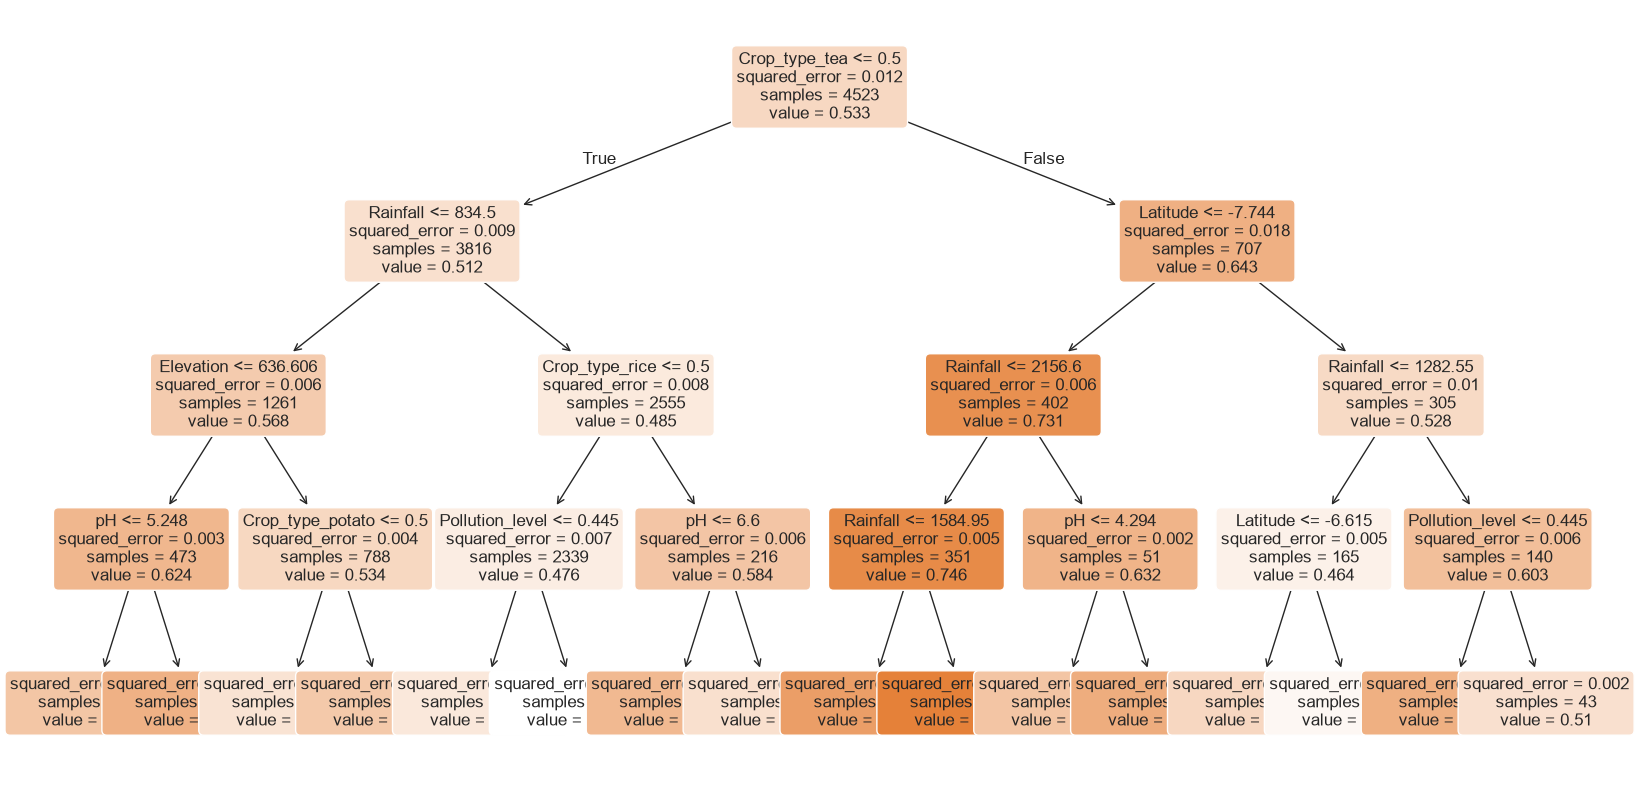

In [120]:
#visualizing the Decision Tree model using the plot_tree function from sklearn.tree module to understand the decision-making process of the model and how it splits the data based on different features.
plt.figure(figsize=(20, 10))
plot_tree(decision_tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=12)
plt.show()

### Exercise 2

While the model shows some predictive capability with a moderate R² value, there is still room for improvement, particularly in reducing the MSE and potentially increasing the explanatory power of the model. This can be achieved through further feature selection, hyperparameter tuning, or exploring alternative modelling techniques.

Let's start with feature selection. What environmental factors have the highest correlation with crop yields, and how can we use this information to improve the predictive performance of our model?

Conduct feature selection using a **correlation matrix** to select relevant features for predicting `Standard_yield`.

Visualise the matrix to better identify the features with the highest correlation with `Standard_yield`.

Regarding features to retain and eliminate, what do the results suggest? Have you thought about the independent features that might be correlated? 


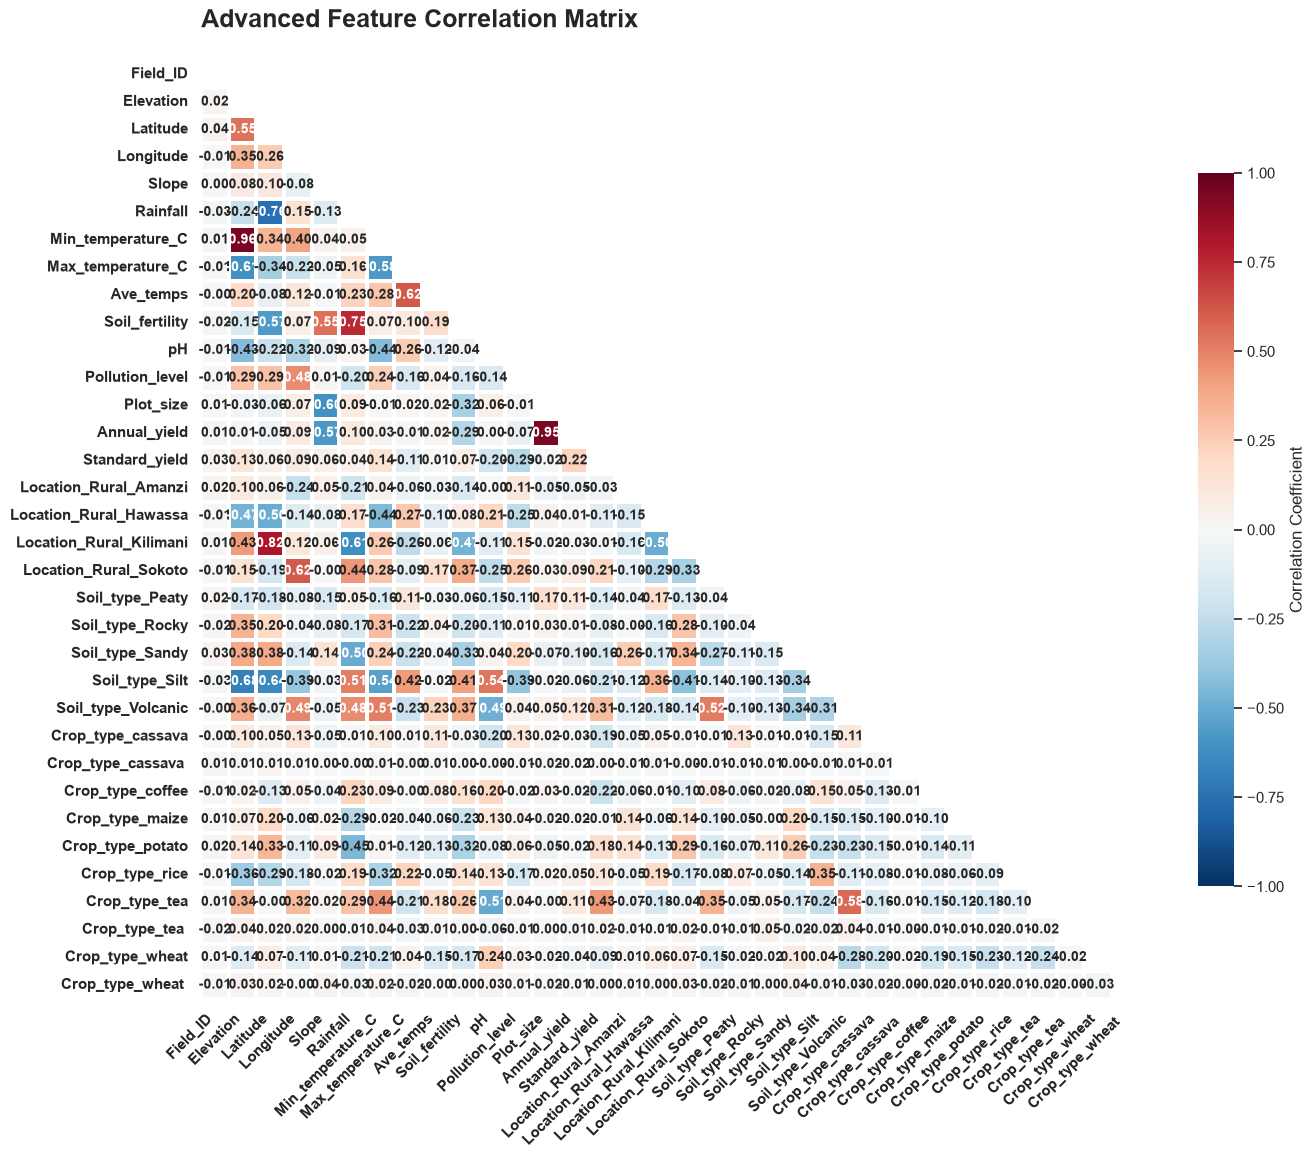

In [121]:
# correlation heatmap to visualize the relationships between the features and the target variable, 
# which can help identify potential multicollinearity issues and inform feature selection for model improvement.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional plotting aesthetics
sns.set_theme(style="white")

# 1. Prepare the figure canvas
plt.figure(figsize=(14, 12), dpi=100)

# 2. Compute correlation matrix (numeric only to prevent errors)
correlation_matrix = df.corr(numeric_only=True)

# 3. Mask the upper triangle (removes redundant duplicate information)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 4. Create a vibrant, center-anchored diverging color palette
# 'RdBu_r' gives vivid Deep Red (+) to Deep Blue (-) with crisp white at 0
vivid_cmap = sns.diverging_palette(240, 10, as_cmap=True)

# 5. Draw the advanced heatmap
correlation_heatmap = sns.heatmap(
    correlation_matrix,
    mask=mask,  # Apply upper triangle mask
    cmap="RdBu_r",  # Vivid diverging color profile
    vmax=1.0,  # Lock maximum color threshold
    vmin=-1.0,  # Lock minimum color threshold
    center=0,  # Force perfectly neutral white at 0.00
    annot=True,  # Display correlation values
    fmt=".2f",  # Limit decimals to 2 places
    square=True,  # Force perfectly square cells
    linewidths=1.5,  # Add crisp borders between cells
    cbar_kws={
        "shrink": 0.7,
        "label": "Correlation Coefficient",
    },  # Style the colorbar
    annot_kws={"size": 10, "weight": "bold"},  # Make inner numbers pop
)

# 6. Polish text elements, angles, and layout
plt.title(
    "Advanced Feature Correlation Matrix",
    fontsize=18,
    fontweight="bold",
    pad=24,
    loc="left",
)
plt.xticks(rotation=45, ha="right", fontsize=11, fontweight="semibold")
plt.yticks(rotation=0, fontsize=11, fontweight="semibold")

# Tighten layout boundary to prevent edge clipping
plt.tight_layout()
plt.show()


In [122]:
# correlation dataframe

# 1. Compute correlation matrix for numeric columns only
corr_matrix = df.corr(numeric_only=True)

# 2. Isolate the target column, drop its self-correlation (1.00), and sort
target_corr = (
    corr_matrix[["Standard_yield"]]
    .drop(labels=["Standard_yield"], axis=0)
    .sort_values(by="Standard_yield", ascending=False)
)

# 3. Convert to a polished DataFrame with clean column names
yield_corr_df = target_corr.reset_index()
yield_corr_df.columns = ["Feature", "Correlation_with_Yield"]

In [123]:
yield_corr_df

,Feature,Correlation_with_Yield
0,Crop_type_tea,0.432667
1,Soil_type_Volcanic,0.309982
2,Annual_yield,0.220812
3,Location_Rural_Sokoto,0.212337
4,Crop_type_potato,0.175484
5,Min_temperature_C,0.144233
6,Elevation,0.129248
7,Crop_type_rice,0.104056
8,Longitude,0.085343
9,Soil_fertility,0.070205


In [124]:
from scipy.stats import pearsonr

correlations = []

for col in df.columns:
    # 1. Skip the target column itself
    if col == "Standard_yield":
        continue

    # 2. Skip text/categorical columns to prevent scipy errors
    if not pd.api.types.is_numeric_dtype(df[col]):
        continue

    # 3. Calculate and append stats
    corr_coef, p_value = pearsonr(df[col], df["Standard_yield"])
    correlations.append(
        {
            "Feature": col,
            "Correlation_Coefficient": corr_coef,
            "P_Value": p_value,
        }
    )

# REMOVED .T so that columns remain columns
correlation_df = pd.DataFrame(correlations)

# This will now work perfectly
df_cp_sorted = correlation_df.sort_values("P_Value")

# Filter for statistically significant features (p < 0.1)
significant_features = df_cp_sorted[df_cp_sorted["P_Value"] < 0.1].reset_index(drop=True)
significant_features


,Feature,Correlation_Coefficient,P_Value
0,Crop_type_tea,0.432667,1.006379e-256
1,Soil_type_Volcanic,0.309982,3.506627e-126
2,Pollution_level,-0.285761,1.041714e-106
3,Crop_type_coffee,-0.222217,3.348618e-64
4,Annual_yield,0.220812,2.141268e-63
5,Location_Rural_Sokoto,0.212337,1.187992e-58
6,Soil_type_Silt,-0.205861,3.664353e-55
7,pH,-0.196613,2.213242e-50
8,Crop_type_cassava,-0.187517,6.579396e-46
9,Crop_type_potato,0.175484,2.456616e-40


In [125]:
# Correlation of the independent variables only
independent_correlations = []

for col in df.columns:
    # 1. Skip the target column itself
    if col == "Standard_yield":
        continue

    # 2. Skip text/categorical columns to prevent scipy errors
    if not pd.api.types.is_numeric_dtype(df[col]):
        continue

    # 3. Calculate and append stats
    corr_coef, p_value = pearsonr(df[col], df["Standard_yield"])
    independent_correlations.append(
        {
            "Feature": col,
            "Correlation_Coefficient": corr_coef,
            "P_Value": p_value,
        }
    )

independent_correlation_df = pd.DataFrame(independent_correlations)
independent_correlation_df_sorted = independent_correlation_df.sort_values("P_Value")
independent_significant_features = independent_correlation_df_sorted[independent_correlation_df_sorted["P_Value"] < 0.1].reset_index(drop=True)
independent_significant_features.sort_values(by="P_Value", ascending=False).reset_index(drop=True)  

,Feature,Correlation_Coefficient,P_Value
0,Field_ID,0.030802,2.054940e-02
1,Location_Rural_Amanzi,-0.032049,1.595457e-02
2,Rainfall,0.039217,3.184966e-03
3,Slope,0.056991,1.803693e-05
4,Latitude,0.061724,3.407176e-06
5,Soil_fertility,0.070205,1.262032e-07
6,Soil_type_Rocky,-0.078355,3.645837e-09
7,Longitude,0.085343,1.296853e-10
8,Crop_type_wheat,-0.093022,2.413169e-12
9,Crop_type_rice,0.104056,4.367781e-15


### Exercise 3
Now that we know which features could work best for our model, let's run our model again on a reduced dataset.

Reduce the dataset to only include `Pollution_level`, `Min_temperature_C`, `Longitude`, and `pH`.

Refit the decision tree regressor model using the reduced dataset and evaluate the model's performance on the test set to determine if there's an improvement in MSE and R² values.

Does reducing the dataset lead to an improvement in the predictive performance of our model?

Run the model on different combinations of the reduced dataset. Is there a combination of variables or a single variable that improves the MSE and R²?

In [126]:
X = df[independent_significant_features["Feature"].tolist()]
y = df['Standard_yield']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [127]:
model = DecisionTreeRegressor(max_depth=4, random_state=42)

In [128]:
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [129]:
# Training and Testing model predictions
decision_tree_train_predictions = model.predict(X_train)
decision_tree_test_predictions = model.predict(X_test)
residuals_train = y_train - decision_tree_train_predictions
residuals_test = y_test - decision_tree_test_predictions

In [130]:
# Training Model Evaluation
train_mse = mean_squared_error(y_train, decision_tree_train_predictions)
train_r2 = r2_score(y_train, decision_tree_train_predictions)
train_rmse = np.sqrt(train_mse)
train_rss = np.sum(residuals_train**2)

# Testing Model Evaluation
test_mse = mean_squared_error(y_test, decision_tree_test_predictions)
test_r2 = r2_score(y_test, decision_tree_test_predictions)
test_rmse = np.sqrt(test_mse)
test_rss = np.sum(residuals_test**2)


significant_model_evaluation = {
    'train_mse': train_mse,
    'train_r2': train_r2,
    'train_rmse': train_rmse,
    'train_rss': train_rss,
    'test_mse': test_mse,
    'test_r2': test_r2,
    'test_rmse': test_rmse,
    'test_rss': test_rss
}

# convert the dictionary to a DataFrame for better visualization
significant_model_evaluation_df = pd.DataFrame(significant_model_evaluation, index=[0])
significant_model_evaluation_df

,train_mse,train_r2,train_rmse,train_rss,test_mse,test_r2,test_rmse,test_rss
0,0.004668,0.619909,0.068322,21.11294,0.004957,0.628026,0.070404,5.606047


### Exercise 4
Now that we have attempted feature engineering, let's move on to parameter tuning. What is the optimal depth for the decision tree model that maximises predictive performance while avoiding overfitting?

Use a loop to fit decision tree models with depths ranging from 1 to 10 and assess the MSE and R² scores for each depth.
Analyse the results to identify the depth that maximises R² while avoiding significant increases in MSE, indicating optimal model complexity.

In [131]:
def decision_test_on_depth(df, num):
    # 1. SPLIT DATA FIRST to eliminate data leakage
    all_features = [col for col in df.columns if col != "Standard_yield"]

    X_all = df[all_features]
    y_all = df["Standard_yield"]

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42
    )

    # 2. FEATURE SELECTION (Using ONLY the training set)
    independent_correlations = []

    for col in X_train_raw.columns:
        if not pd.api.types.is_numeric_dtype(X_train_raw[col]):
            continue

        valid_data = pd.concat([X_train_raw[col], y_train], axis=1).dropna()
        if len(valid_data) < 2:
            continue

        corr_coef, p_value = pearsonr(
            valid_data[col], valid_data["Standard_yield"]
        )
        independent_correlations.append(
            {
                "Feature": col,
                "Correlation_Coefficient": corr_coef,
                "P_Value": p_value,
            }
        )

    independent_correlation_df = pd.DataFrame(independent_correlations)
    independent_significant_features = independent_correlation_df[
        independent_correlation_df["P_Value"] < 0.1
    ].sort_values("P_Value")

    selected_features = independent_significant_features["Feature"].tolist()

    if not selected_features:
        print("Warning: No features met p < 0.1. Using all numeric features.")
        selected_features = [
            col
            for col in X_train_raw.columns
            if pd.api.types.is_numeric_dtype(X_train_raw[col])
        ]

    X_train = X_train_raw[selected_features]
    X_test = X_test_raw[selected_features]

    # Print a header for the live outputs before the loop begins
    print(f"{'Depth':<6} | {'Train RMSE':<12} | {'Test RMSE':<12} | {'Train R2':<10} | {'Test R2':<10}")
    print("=" * 70)

    # 3. ITERATIVE MODEL EVALUATION
    results = []
    for depth in range(1, num + 1):
        model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)

        # Model predictions
        decision_tree_train_predictions = model.predict(X_train)
        decision_tree_test_predictions = model.predict(X_test)

        # Residuals
        residuals_train = y_train - decision_tree_train_predictions
        residuals_test = y_test - decision_tree_test_predictions

        # Training Evaluation
        train_mse = mean_squared_error(y_train, decision_tree_train_predictions)
        train_r2 = r2_score(y_train, decision_tree_train_predictions)
        train_rmse = np.sqrt(train_mse)
        train_rss = np.sum(residuals_train**2)

        # Testing Evaluation
        test_mse = mean_squared_error(y_test, decision_tree_test_predictions)
        test_r2 = r2_score(y_test, decision_tree_test_predictions)
        test_rmse = np.sqrt(test_mse)
        test_rss = np.sum(residuals_test**2)

        df_depth = pd.DataFrame(
            {
                "depth": [depth],
                "train_mse": [train_mse],
                "train_r2": [train_r2],
                "train_rmse": [train_rmse],
                "train_rss": [train_rss],
                "test_mse": [test_mse],
                "test_r2": [test_r2],
                "test_rmse": [test_rmse],
                "test_rss": [test_rss],
            }
        )

        results.append(df_depth)

        # LIVE OUTPUT: Displays immediately during each individual depth pass
        print(
            f"{depth:<6} | {train_rmse:<12.4f} | {test_rmse:<12.4f} | {train_r2:<10.4f} | {test_r2:<10.4f}"
        )

    print("=" * 70)  # Closing boundary line
    return pd.concat(results, ignore_index=True)


In [132]:
decision_test_on_depth(df, 20)

Depth  | Train RMSE   | Test RMSE    | Train R2   | Test R2   
1      | 0.1001       | 0.1035       | 0.1842     | 0.1954    
2      | 0.0846       | 0.0882       | 0.4168     | 0.4165    
3      | 0.0753       | 0.0782       | 0.5382     | 0.5411    
4      | 0.0683       | 0.0704       | 0.6199     | 0.6280    
5      | 0.0613       | 0.0636       | 0.6940     | 0.6964    
6      | 0.0543       | 0.0587       | 0.7602     | 0.7411    
7      | 0.0469       | 0.0524       | 0.8207     | 0.7939    
8      | 0.0406       | 0.0488       | 0.8659     | 0.8211    
9      | 0.0340       | 0.0434       | 0.9059     | 0.8589    
10     | 0.0282       | 0.0394       | 0.9354     | 0.8833    
11     | 0.0232       | 0.0359       | 0.9562     | 0.9034    
12     | 0.0189       | 0.0358       | 0.9709     | 0.9037    
13     | 0.0155       | 0.0339       | 0.9804     | 0.9136    
14     | 0.0129       | 0.0340       | 0.9865     | 0.9131    
15     | 0.0108       | 0.0340       | 0.9905     | 0.9

,depth,train_mse,train_r2,train_rmse,train_rss,test_mse,test_r2,test_rmse,test_rss
0,1,0.010019,0.184178,0.100096,45.316553,0.010722,0.195369,0.103547,12.126639
1,2,0.007162,0.416800,0.084630,32.395065,0.007775,0.416507,0.088178,8.793850
2,3,0.005671,0.538248,0.075305,25.648991,0.006115,0.541126,0.078196,6.915714
3,4,0.004668,0.619909,0.068322,21.112940,0.004957,0.628026,0.070404,5.606047
4,5,0.003758,0.694005,0.061302,16.997165,0.004046,0.696405,0.063605,4.575505
5,6,0.002945,0.760189,0.054269,13.320816,0.003450,0.741079,0.058739,3.902215
6,7,0.002202,0.820679,0.046928,9.960755,0.002746,0.793918,0.052404,3.105876
7,8,0.001647,0.865901,0.040582,7.448832,0.002384,0.821127,0.048822,2.695799
8,9,0.001155,0.905935,0.033988,5.225035,0.001880,0.858892,0.043363,2.126645
9,10,0.000794,0.935375,0.028172,3.589736,0.001554,0.883347,0.039427,1.758085


## Solutions

### Exercise 1

In [133]:

# Drop non-numeric columns
non_numeric_columns = ['Location', 'Soil_type', 'Crop_type']
#split data into dependent and independent variables
X = dataset.drop(columns=['Standard_yield'] + non_numeric_columns)
y = dataset['Standard_yield']
    
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
# Train the model
model = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_train, y_train)
predictions = model.predict(X_test)
    
# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
    
result = {'mse': mse, 'r2': r2, 'model_depth': model.get_depth()}
result



{'mse': 0.007852911867489898, 'r2': 0.3895258341057801, 'model_depth': 4}

While the model shows some predictive capability with a moderate R² value, there is still room for improvement, particularly in reducing the MSE and potentially increasing the explanatory power of the model.

### Exercise 2

Correlation with Standard_yield:
 Standard_yield       1.000000
Annual_yield         0.220812
Min_temperature_C    0.144233
Elevation            0.129248
Longitude            0.085343
Soil_fertility       0.070205
Latitude             0.061724
Slope                0.056991
Rainfall             0.039217
Field_ID             0.030802
Unnamed: 0           0.023505
Ave_temps            0.006786
Plot_size           -0.017014
Max_temperature_C   -0.111649
pH                  -0.196613
Pollution_level     -0.285761
Name: Standard_yield, dtype: float64


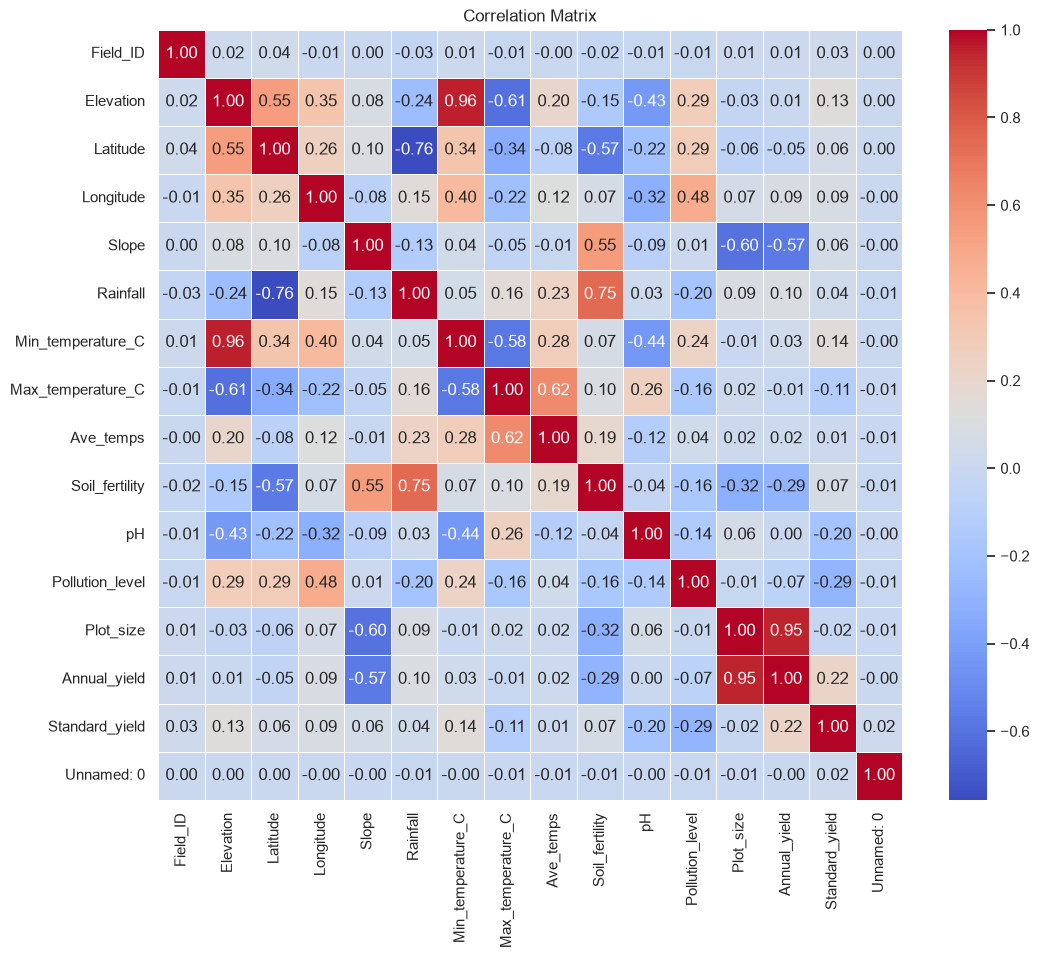

In [134]:


# 1. Correlation Analysis
non_numeric_dataset = dataset.drop(columns = ['Location', 'Soil_type', 'Crop_type'])
correlation_matrix = non_numeric_dataset.corr()
print("Correlation with Standard_yield:\n", correlation_matrix['Standard_yield'].sort_values(ascending=False))

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


Based on the resulting correlation matrix, we would retain the variables with comparatively higher positive or negative absolute correlation coefficients, such as Annual_yield, Min_temperature_C, pH, Pollution_level, and Soil_fertility, and exclude the ones with lower correlation coefficients. It is however important to also use some knowledge we have in how the Standard_yield variable was created – we used Annual_yield as an input, and as such, including it as a predictive variable should be carefully thought about. Let's see what happens if we don't include it for now.  

This will help us retain the most influential features for predicting crop yields while reducing the complexity of the model.

### Exercise 3

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define the features to keep based on correlation analysis
features_to_keep = ['Pollution_level','Min_temperature_C','Longitude','pH']

# Prepare the dataset with only the selected features
X = dataset[features_to_keep]
y = dataset['Standard_yield']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the decision tree model
model = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Store the results
result = {'mse': mse, 'r2': r2, 'model_depth': model.get_depth()}
result



{'mse': 0.008844274351502885, 'r2': 0.3124587288410299, 'model_depth': 4}


The model's performance has not improved. The MSE has increased and the R-squared value has decreased. This indicates that using only the selected features has led to a worse predictive performance compared to the previous model. This illustrates the cost of simplified models – we're losing predictive ability whilst gaining ease of interpretation. It's also worth remembering that the R-squared value generally increases as more variables are added – which shouldn't tempt us to do so without good reason!

### Exercise 4

In [136]:
# Define a range of depths to try
depths_to_try = range(1, 11)

# Initialise empty lists to store results
mse_scores = []
r2_scores = []

# Iterate over depths and fit models
for depth in depths_to_try:
    # Train the model
    model = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Evaluate the model
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    # Append scores to lists
    mse_scores.append(mse)
    r2_scores.append(r2)

# Print the results
for depth, mse, r2 in zip(depths_to_try, mse_scores, r2_scores):
    print(f"Depth: {depth}, MSE: {mse}, R2: {r2}")


Depth: 1, MSE: 0.011346751164118245, R2: 0.11791975137262489
Depth: 2, MSE: 0.009765370470906087, R2: 0.24085403052155063
Depth: 3, MSE: 0.00902979208907587, R2: 0.2980368445751046
Depth: 4, MSE: 0.008844274351502885, R2: 0.3124587288410299
Depth: 5, MSE: 0.00866221343822956, R2: 0.32661188451728207
Depth: 6, MSE: 0.008533708422990784, R2: 0.33660168108126565
Depth: 7, MSE: 0.00894024607176622, R2: 0.30499802421759703
Depth: 8, MSE: 0.009677506334365895, R2: 0.2476844631523366
Depth: 9, MSE: 0.00976898927915278, R2: 0.2405727095309158
Depth: 10, MSE: 0.01027240093112741, R2: 0.20143820585554528


As the depth of the decision tree increases, the MSE generally decreases initially until reaching a minimum at depth 6. Beyond that, the MSE starts to increase again.

The R-squared values also show a similar trend to MSE, initially increasing until depth 6 is reached, and then slightly decreasing afterwards.

Depth 6 seems to provide the best balance between model complexity and performance, as it has the lowest MSE among depths 1 to 5 and a relatively high R² value compared to other depths.

Beyond depth 6, increasing the depth of the decision tree leads to overfitting, as indicated by the increasing MSE and decreasing R-squared values. This means the model starts capturing noise in the data rather than true patterns, resulting in poorer performance on unseen data.

As a final piece of testing (see it as a reward), select only the cassava crops and fit a decision tree to it. Tip: add in the Rainfall variable. The R-squared value is significantly higher than we had for our model. This suggests that we might need to break down the model into decision trees for each crop or use dummy variables when creating it. Sometimes it's useful to approach the same data from different angles, as a fitted model can probably always be improved! 


#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/ExploreAI_logos/EAI_Blue_Dark.png"  style="width:200px";/>
</div>